In [335]:
# 분류, 회귀
# 의사 결정트리 (스케일이 필요없음) => 트리 1개
# ------------------------------------------
# 랜덤포레스트 => 트리를 여러개 병렬로 학습후 평균
# ------------------------------------------


# XGBoost => 트리를 여러개 순차적으로 1개씩 추가하면서 보정
# LightGBM => 트리를 여러개 효율적인 노드만 순차적으로 추가 보정(속도가 빠름)

# 이 기법들도 loss를 줄여나가면서 적용.
# 가격 예측에 좋음 오히려 딥러닝 보다 좋음
#
# XGBoost: 데이터가 적을때 꼼꼼하게
# LightGBM: 데이터가 많을때 성능이 좋음 (100만건 이상 쯤)

In [336]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/UniversalBank01.csv")
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [337]:
# 고객아이디, 나이, 경력, 연소득, 우편번호, 가족수, 월평균신용카드사용액, 교육수준, 주택담보대출금액, 개인대출가입여부,
# 증권계좌보유, 인터넷뱅킹사용, 예금계좌, 신용카드보유, 

df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'PersonalLoan', 'SecuritiesAccount',
       'CDAccount', 'Online', 'CreditCard'],
      dtype='object')

In [338]:
hangul_column_names = [
    "고객아이디",
    "나이",
    "경력",
    "연소득",
    "우편번호",
    "가족수",
    "월평균신용카드사용액",
    "교육수준",
    "주택담보대출금액",
    "개인대출가입여부",
    "증권계좌보유",
    "예금계좌",
    "인터넷뱅킹사용",
    "신용카드보유",
]

In [339]:
t1 = dict(zip(df.columns, hangul_column_names))
t1

{'ID': '고객아이디',
 'Age': '나이',
 'Experience': '경력',
 'Income': '연소득',
 'ZIP Code': '우편번호',
 'Family': '가족수',
 'CCAvg': '월평균신용카드사용액',
 'Education': '교육수준',
 'Mortgage': '주택담보대출금액',
 'PersonalLoan': '개인대출가입여부',
 'SecuritiesAccount': '증권계좌보유',
 'CDAccount': '예금계좌',
 'Online': '인터넷뱅킹사용',
 'CreditCard': '신용카드보유'}

In [340]:
df = df.rename(columns=t1)
df.columns

Index(['고객아이디', '나이', '경력', '연소득', '우편번호', '가족수', '월평균신용카드사용액', '교육수준',
       '주택담보대출금액', '개인대출가입여부', '증권계좌보유', '예금계좌', '인터넷뱅킹사용', '신용카드보유'],
      dtype='object')

In [341]:
df['예금계좌'].value_counts()

예금계좌
0    4698
1     302
Name: count, dtype: int64

In [342]:
df.dtypes

고객아이디           int64
나이              int64
경력              int64
연소득             int64
우편번호            int64
가족수             int64
월평균신용카드사용액    float64
교육수준            int64
주택담보대출금액        int64
개인대출가입여부        int64
증권계좌보유          int64
예금계좌            int64
인터넷뱅킹사용         int64
신용카드보유          int64
dtype: object

In [343]:
y = df['개인대출가입여부'].values
x = df.drop(columns=["고객아이디", "우편번호", "개인대출가입여부"]).values

x.shape, y.shape

((5000, 11), (5000,))

In [344]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, train_size=0.8, random_state=123)
x_train.shape, x_test.shape, y_train.shape, y_test.shape, 

((4000, 11), (1000, 11), (4000,), (1000,))

In [345]:
# 모델 생성
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=4, random_state=123)
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [346]:
model.score(x_train, y_train), model.score(x_test, y_test)

(0.98675, 0.981)

In [347]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(x_test)

confusion_matrix(y_test, y_pred)

array([[901,   3],
       [ 16,  80]])

In [348]:
df1 = df.drop(columns=["고객아이디", "우편번호", "개인대출가입여부"])
df1.columns

Index(['나이', '경력', '연소득', '가족수', '월평균신용카드사용액', '교육수준', '주택담보대출금액', '증권계좌보유',
       '예금계좌', '인터넷뱅킹사용', '신용카드보유'],
      dtype='object')

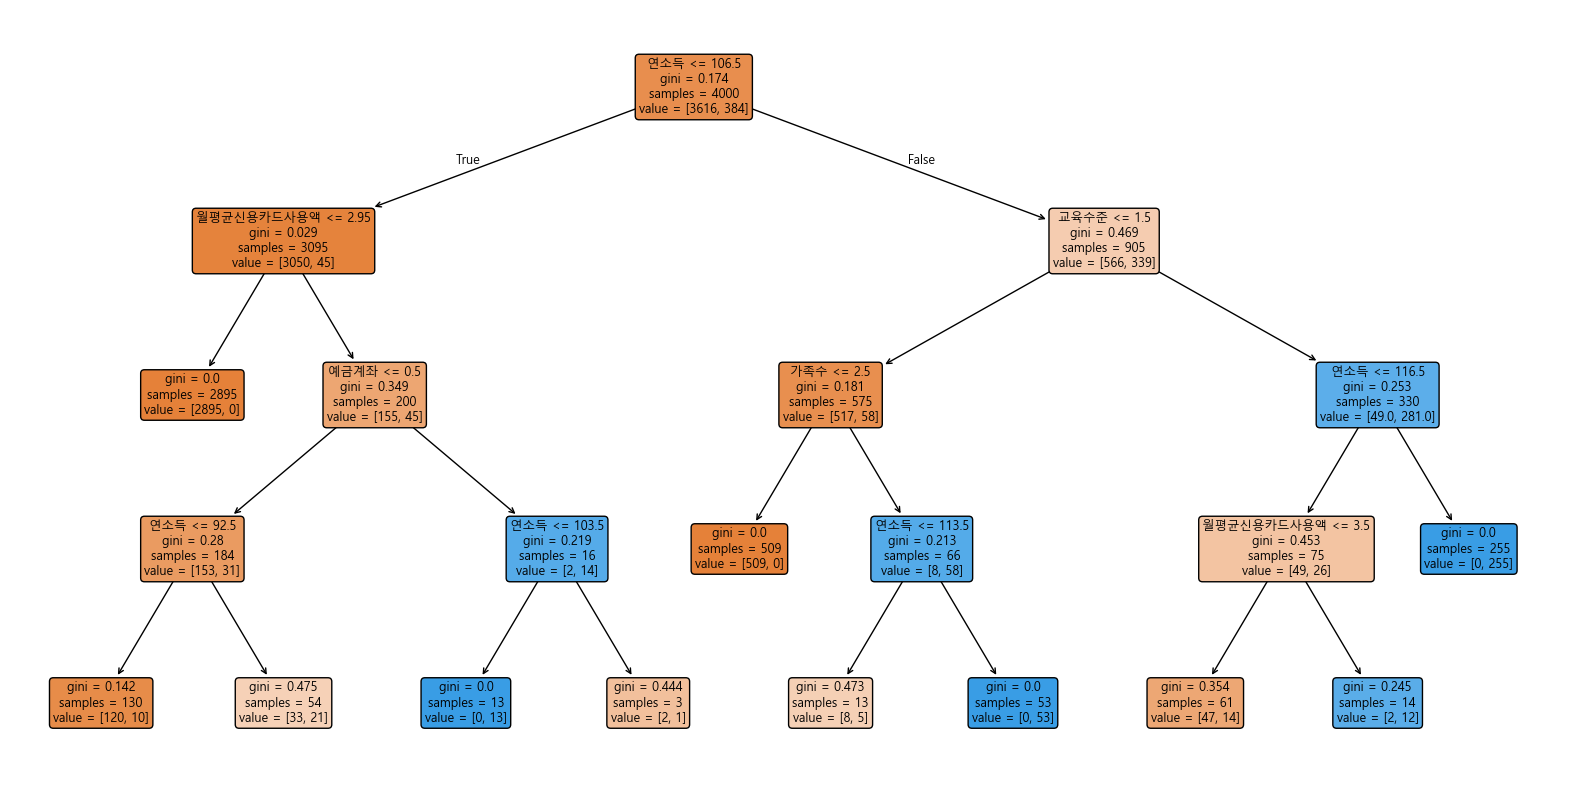

In [349]:
import matplotlib.pyplot as plt
from seaborn_cjk import patch

patch()

from sklearn.tree import plot_tree

plt.figure(figsize=(20,  10))
plot_tree(
    model, filled=True, rounded=True, feature_names=df1.columns
)
plt.show()

In [350]:
# 특성

import pandas as pd

df2 = pd.DataFrame({'특성': df1.columns, '중요도': model.feature_importances_})
df2.sort_values(by="중요도", ascending=False)


,특성,중요도
2,연소득,0.402368
5,교육수준,0.382549
3,가족수,0.146099
4,월평균신용카드사용액,0.045191
8,예금계좌,0.023793
0,나이,0.000000
1,경력,0.000000
6,주택담보대출금액,0.000000
7,증권계좌보유,0.000000
9,인터넷뱅킹사용,0.000000


In [351]:
! pip install xgboost

In [352]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/bike_sharing_demand_train.csv")


In [353]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [354]:
# 날짜시간, 계절, 공휴일여부, 평일여부, 날씨상태, 실제온도, 체감온도, 습도, 풍속, 비회원대여수, 등록회원대여수, 총대여수
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [355]:
hangul_column_names = [
    "날짜시간",
    "계절",
    "공휴일여부",
    "평일여부",
    "날씨상태",
    "실제온도",
    "체감온도",
    "습도",
    "풍속",
    "비회원대여수",
    "등록회원대여수",
    "총대여수",
]

In [356]:
t1 = dict(zip(df.columns, hangul_column_names))
t1

{'datetime': '날짜시간',
 'season': '계절',
 'holiday': '공휴일여부',
 'workingday': '평일여부',
 'weather': '날씨상태',
 'temp': '실제온도',
 'atemp': '체감온도',
 'humidity': '습도',
 'windspeed': '풍속',
 'casual': '비회원대여수',
 'registered': '등록회원대여수',
 'count': '총대여수'}

In [357]:
df = df.rename(columns=t1)
df.columns

Index(['날짜시간', '계절', '공휴일여부', '평일여부', '날씨상태', '실제온도', '체감온도', '습도', '풍속',
       '비회원대여수', '등록회원대여수', '총대여수'],
      dtype='object')

In [358]:
df['날짜시간'] = pd.to_datetime(df['날짜시간'])

In [359]:
# 날짜에서 시간, 요일, 달, 년을 꺼내서 특성을 추가함
df['시간'] = df['날짜시간'].dt.hour
df['요일'] = df['날짜시간'].dt.weekday
df['달'] = df['날짜시간'].dt.month
df['년'] = df['날짜시간'].dt.year

In [360]:
y = df['총대여수'].values
x_df = df.drop(columns=['날짜시간', '비회원대여수', '등록회원대여수', '총대여수'])
x = df.drop(columns=['날짜시간', '비회원대여수', '등록회원대여수', '총대여수']).values

print(x.shape, y.shape)
print(x_df.columns.to_list())

(10886, 12) (10886,)
['계절', '공휴일여부', '평일여부', '날씨상태', '실제온도', '체감온도', '습도', '풍속', '시간', '요일', '달', '년']


In [361]:
# 분할
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8708, 12), (2178, 12), (8708,), (2178,))

In [ ]:
model = XGBRegressor()

model.fit(
    x_train,
    y_train,
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [363]:
from sklearn.metrics import r2_score
y_pred = model.predict(x_test)
r2_score(y_pred, y_test)

0.9519566893577576

In [ ]:
! pip install xgboost matplotlib graphviz

Note: you may need to restart the kernel to use updated packages.


In [365]:
import os
import sys

# 윈도우 기준 기본 설치 경로를 시스템 PATH 변수에 수동으로 추가합니다.
# 설치 시 경로를 바꾸셨다면 아래 주소를 해당 경로로 변경해 주세요.
graphviz_path = r"C:\utils\Graphviz-15.0.0-win64\bin"

if graphviz_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.path.pathsep + graphviz_path

print("PATH 등록 완료!")

PATH 등록 완료!


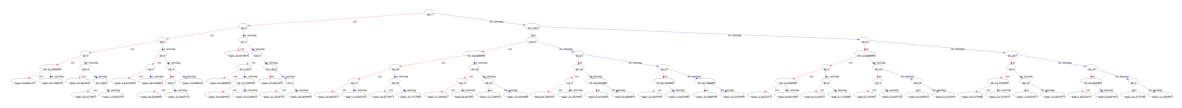

In [366]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split




# 3. Plot a specific decision tree
fig, ax = plt.subplots(figsize=(15, 10))
# num_trees=0 plots the very first tree built by the boosting process
xgb.plot_tree(model, tree_idx=0, ax=ax)

# 4. Display or save the plot
plt.show()
# Optional: Save the tree image file
# plt.savefig("xgboost_tree.png", dpi=300, bbox_inches='tight')


In [ ]:
! pip install dtreeviz

In [368]:
df.columns

Index(['날짜시간', '계절', '공휴일여부', '평일여부', '날씨상태', '실제온도', '체감온도', '습도', '풍속',
       '비회원대여수', '등록회원대여수', '총대여수', '시간', '요일', '달', '년'],
      dtype='object')

In [369]:
import dtreeviz

feature_names= x_df.columns.to_list()
# Ensure you pass your trained booster, features, and target data
viz_model = dtreeviz.model(
    model, 
    X_train=x_train, 
    y_train=y_train, 
    feature_names=feature_names, 
    target_name="target", 
    tree_index=0
)

v = viz_model.view(fontname="Malgun Gothic")
# View a specific tree index
v


In [ ]:
import xgboost as xgbimport 
import matplotlib.pyplot as plot_tree

booster = model.get_booster()
# plt.figure(figsize=(20, 20))
fig, ax = plt.subplots(figsize=(100, 10))
xgb.plot_tree(booster, tree_idx=0, ax=ax)
plt.show()